In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import MeanShift
import random
from concurrent.futures import ProcessPoolExecutor
from tqdm.notebook import tqdm
from PBR import PBR

In [2]:
params_alpha = np.load('param_alpha.npy')

In [3]:
np.random.seed(84)
random.seed(84)

In [4]:
pd.options.display.max_seq_items = 2000

In [5]:
reconciled_data = pd.read_pickle('reconciled_data.pkl')

data = reconciled_data.loc[reconciled_data.CINÉTICA == True]

X = data[['T_R_C']]
clustering = MeanShift(bandwidth=2).fit(X)

data['cluster'] = clustering.labels_

cluster_set = list(set(data.cluster))

index_clusters = data.groupby('cluster').T_R_C.mean().sort_values().index.values

val_clusters = index_clusters[[2, 4]]
test_clusters = index_clusters[[6]]
train_clusters = index_clusters[[0,1,3,5]]

loc_validation = data['cluster'].isin(val_clusters)
loc_training =  data['cluster'].isin(train_clusters)
loc_test = data['cluster'].isin(test_clusters)

idx_validation = loc_validation.loc[loc_validation].index
idx_training = loc_training.loc[loc_training].index
idx_test = loc_test.loc[loc_test].index

data['training'] = loc_training

In [6]:
data.groupby(['cluster'])['T_R_C'].mean().sort_values()

cluster
3    211.000000
0    222.000000
2    233.000000
1    243.687500
6    253.500000
5    262.545455
4    271.000000
Name: T_R_C, dtype: float64

In [7]:
Ns_parafins = {
    'F_CH4_s_mol_s': 1, 'F_C2H6_s_mol_s': 2, 'F_C3H8_s_mol_s': 3,
       'F_C9': 9, 'F_C10': 10, 'F_C11': 11, 'F_C12': 12, 'F_C13': 13, 'F_C14': 14, 'F_C15': 15, 'F_C16': 16,
       'F_C17': 17, 'F_C18': 18, 'F_C19': 19, 'F_C20': 20, 'F_C21': 21, 'F_C22': 22, 'F_C23': 23, 'F_C24': 24,
       'F_C25': 25, 
       'F_C26': 26, 'F_C27': 27, 'F_C28': 28, 'F_C29': 29, 'F_C30': 30,
       'F_C31': 31, 'F_C32': 32,
       'F_C33': 33, 'F_C34': 34,
       'F_C35': 35, 
       'F_C36': 36,
}
Ns_olefins = {
    'F_C2H4_s_mol_s': 2,
       'F_Olef_C9': 9, 'F_Olef_C10': 10,
       'F_Olef_C11': 11, 'F_Olef_C12': 12, 'F_Olef_C13': 13, 'F_Olef_C14': 14, 'F_Olef_C15': 15,
       'F_Olef_C16': 16, 'F_Olef_C17': 17, 
       'F_Olef_C18': 18, 
}

In [8]:
MM_parafins = {comp: n * 12 + 2 * n + 2 for comp, n in Ns_parafins.items()}
MM_olefins = {comp: n * 12 + 2 * n for comp, n in Ns_olefins.items()}

In [9]:
Fn_exp_parafins = data[list(Ns_parafins.keys())]

Fn_exp_olefins = data[list(Ns_olefins.keys())]

mn_exp_parafins = Fn_exp_parafins.mul(MM_parafins, axis = 'columns')
mn_exp_olefins = Fn_exp_olefins.mul(MM_olefins, axis = 'columns')

Fn_exp_parafins.columns = Ns_parafins.values()
Fn_exp_parafins.columns = Fn_exp_parafins.columns.astype('int32')

mn_exp_parafins.columns = Ns_parafins.values()
mn_exp_parafins.columns = mn_exp_parafins.columns.astype('int32')

Fn_exp_olefins.columns = Ns_olefins.values()
Fn_exp_olefins.columns = Fn_exp_olefins.columns.astype('int32')

mn_exp_olefins.columns = Ns_olefins.values()
mn_exp_olefins.columns = mn_exp_olefins.columns.astype('int32')

In [10]:
Fn_exp = Fn_exp_parafins.copy()
mn_exp = mn_exp_parafins.copy()

In [11]:
for i in Ns_olefins.values():
    Fn_exp[i] = Fn_exp[i] + Fn_exp_olefins[i]
    mn_exp[i] = mn_exp_parafins[i] + mn_exp_olefins[i]

In [12]:
# drop rows with zeros
# Fn_exp = Fn_exp[(Fn_exp != 0).all(axis=1)]
Fn_exp = Fn_exp.astype('float')

# mn_exp = mn_exp[(mn_exp != 0).all(axis=1)]
mn_exp = mn_exp.astype('float')

In [13]:
data = data.loc[Fn_exp.index].copy()

In [14]:
yn_exp = Fn_exp.div(Fn_exp.sum(axis = 'columns'), axis = 'rows')
omega_n_exp = mn_exp.div(mn_exp.sum(axis = 'columns'), axis = 'rows')

In [15]:
sigma_Fn_exp = Fn_exp * 0.05

In [16]:
Fout_exp = Fn_exp.sum(axis = 'columns')
sigma_Fout_exp = Fout_exp * 0.05

In [17]:
# now to check the modified activation energies for C1-C2

In [18]:
from models_FTS.Mousavi_C1_C2_Emod import Mousavi 

In [19]:
parafins = [ 'methane', 'ethane', 'propane', 
             # 'butane', 'pentane', 'hexane', 
             #   'heptane', 'octane', 
             'nonane', 'decane', 'undecane', 'dodecane',
               'tridecane', 'tetradecane', 'pentadecane', 'hexadecane', 'heptadecane',
               'octadecane', 'nonadecane', 'eicosane', 'heneicosane', 'docosane',
               'tricosane', 'tetracosane', 'pentacosane',
               'hexacosane', 'heptacosane',
               'octacosane', 'nonacosane', 'triacontane',
             'hentriacontane', 'dotriacontane',
               'tritriacontane', 'tetratriacontane', 'pentatriacontane', 'hexatriacontane'
            ]

olefins = [ 'ethylene',
            # 'propene',
            # '1-butene', '1-pentene', '1-hexene',
            # '1-heptene', '1-octene', 
            '1-nonene', '1-decene',
            '1-undecene', '1-dodecene',
            '1-tridecene', '1-tetradecene', '1-pentadecene',
            '1-hexadecene', '1-heptadecene', '1-octadecene',
          ]

others = ['carbon monoxide', 'hydrogen', 'water', 'carbon dioxide']

In [20]:
def solve_ODEs(index, row):
    results = {}
    F0 = row['F_H2_e_mol_s'] + row['F_CO_e_mol_s']

    H2_CO = row['H2_CO']
    x_CO = 1 / ( 1 + H2_CO )
    x_H2 = 1 - x_CO

    # create reactor object
    T0 = (row['T_R_K'], 'K')
    x0 = {
                      'carbon monoxide': x_CO,
                      'hydrogen' : x_H2,
                  }
    reactor = PBR(T0 = T0, 
                  P0 = (row['P_abs_Pa'], 'Pa'), 
                  x0 = x0, 
                  F0 = (F0, 'mol/s'),
                  isothermal = True, 
                  ergun = False,
                  WT = (row['m_cat_g'], 'g'), 
                  W_steps = 50,
                  U = (300, 'W/m2/K'),
                  D = (7, 'mm'),
                  Dp = (0.1, 'mm'),
                  pellet_density = (2530, 'kg/m3'),
                  Ta = T0,
                  liquid_phase = False,
                  units = 'SI',
                  solver_method = 'BDF',
                  rtol = 1e-5, atol = 1e-7,
                  calculate_equilibrium = False,
                  equilibrium_obj_fun_tolerance = 1e-12,
                  log = True,
                 )

    Mousavi_model = Mousavi()
    reactor.add_model(Mousavi_model)
    reactor.solve()

    sol_df = reactor.sol_dfs['Mousavi']

    for component in parafins + olefins + others:
        results[f'Fout_{component}'] = sol_df.loc[
            (sol_df.W == sol_df.W.max()) & (sol_df.variable == component)].value.values[-1]

    Q_unit = sol_df.loc[(sol_df.W == sol_df.W.max()) & (sol_df.variable == 'Q')]['value units'].values[-1]
    results[f'Q ({Q_unit})'] = sol_df.loc[(sol_df.W == sol_df.W.max()) & (sol_df.variable == 'Q')].value.values[-1]
    return index, results

In [21]:
data_for_simulation = data[[
    'T_R_K', 'P_abs_Pa', 'F_H2_e_mol_s', 'F_CO_e_mol_s', 'm_cat_g', 'H2_CO'
]]

# Determine number of workers (e.g., 4 or use os.cpu_count())
num_workers = 4

print(f"Starting parallel simulation with {num_workers} workers...")

# Prepare the list of tasks
tasks = [(idx, row) for idx, row in data_for_simulation.iterrows()]

# Execute in parallel
results_list = []
with ProcessPoolExecutor(max_workers=num_workers) as executor:
    # We use a wrapper or starmap-like approach
    futures = [executor.submit(solve_ODEs, *task) for task in tasks]
    
    for future in tqdm(futures, total=len(futures)):
        idx, res = future.result()
        # Update the dataframe with results
        for col, val in res.items():
            data_for_simulation.loc[idx, col] = val

# Save final results
data_for_simulation.to_pickle('simulations_Mousavi_C1_C2mod.pkl')
data_for_simulation.to_excel('simulations_Mousavi_C1_C2mod.ods')
print("Simulations complete.")

In [22]:
data_for_simulation = pd.read_pickle('simulations_Mousavi_C1_C2mod.pkl')

In [23]:
cols_Fout = [f'Fout_{comp}' for comp in parafins + olefins + others] 

In [24]:
from models_FTS.chain_length import n_parafins, n_olefins 

In [25]:
N = {}
for comp in parafins:
    N[f'Fout_{comp}'] = n_parafins[comp]
for comp in olefins:
    N[f'Fout_{comp}'] = n_olefins[comp]

In [26]:
cols_Fout_C1_C8 = ['Fout_methane',
 'Fout_ethane',
 'Fout_propane',
 # 'Fout_butane',
 # 'Fout_pentane',
 # 'Fout_hexane',
 # 'Fout_heptane',
 # 'Fout_octane',
 'Fout_ethylene',
 # 'Fout_propene',
 # 'Fout_1-butene',
 # 'Fout_1-pentene',
 # 'Fout_1-hexene',
 # 'Fout_1-heptene',
 # 'Fout_1-octene'
                  ]

In [27]:
cols_Fout_C9_C15 = [
 'Fout_nonane',
 'Fout_decane',
 'Fout_undecane',
 'Fout_dodecane',
 'Fout_tridecane',
 'Fout_tetradecane',
 'Fout_pentadecane',
 'Fout_1-nonene',
 'Fout_1-decene',
 'Fout_1-undecene',
 'Fout_1-dodecene',
 'Fout_1-tridecene',
 'Fout_1-tetradecene',
 'Fout_1-pentadecene',
]

In [28]:
cols_Fout_C16p = [
 'Fout_hexadecane',
 'Fout_heptadecane',
 'Fout_octadecane',
 'Fout_nonadecane',
 'Fout_eicosane',
 'Fout_heneicosane',
 'Fout_docosane',
 'Fout_tricosane',
 'Fout_tetracosane',
 'Fout_pentacosane',
 'Fout_hexacosane',
 'Fout_heptacosane',
 'Fout_octacosane',
 'Fout_nonacosane',
 'Fout_triacontane',
 'Fout_hentriacontane',
 'Fout_dotriacontane',
 'Fout_tritriacontane',
 'Fout_tetratriacontane',
 'Fout_pentatriacontane',
 'Fout_hexatriacontane',
 'Fout_1-hexadecene',
 'Fout_1-heptadecene',
 'Fout_1-octadecene',
]

In [29]:
# visualizing yn
yn_plot = yn_exp.copy()
yn_plot['T_R_K'] = data.T_R_K
yn_plot['T_R_C'] = data.T_R_C
yn_plot['H2_CO'] = data.H2_CO
yn_plot['P_Pa'] = data.P_abs_Pa
yn_plot['index'] = data.index.values
yn_plot = yn_plot.melt(id_vars = ['T_R_K', 'T_R_C', 
                                  'H2_CO', 'P_Pa', 'index'], value_name = 'yn_exp', var_name = 'n')
yn_plot['alpha'] = params_alpha[0] + params_alpha[1] * data.T_R_K
yn_plot['yn_model'] = ( 1 - yn_plot.alpha.values ) * yn_plot.alpha.values ** ( yn_plot.n.values - 1 )

In [30]:
yn_plot['sigma_yn_exp'] = 0.001

In [31]:
Fn_model = data_for_simulation[N.keys()].T.groupby(N).sum().T

In [32]:
yn_C1_C1_model = Fn_model.div(Fn_model.sum(axis = 'columns'), axis = 'rows')

In [33]:
yn_plot['yn_C1_C1_mod_model'] = yn_C1_C1_model.melt().value

In [34]:
yn_plot['data_set'] = 'training'
yn_plot.loc[yn_plot['index'].isin(idx_test) ,'data_set'] = 'test'
yn_plot.loc[yn_plot['index'].isin(idx_validation) ,'data_set'] = 'validation'

In [35]:
X = yn_plot[['T_R_C']]
clustering = MeanShift(bandwidth=2).fit(X)

yn_plot['cluster_T'] = clustering.labels_

In [36]:
yn_plot_mean = yn_plot.groupby(['cluster_T', 'n', 'data_set']).mean()

In [37]:
yn_plot_mean['T_R_C'] = yn_plot_mean['T_R_C'].round(0)

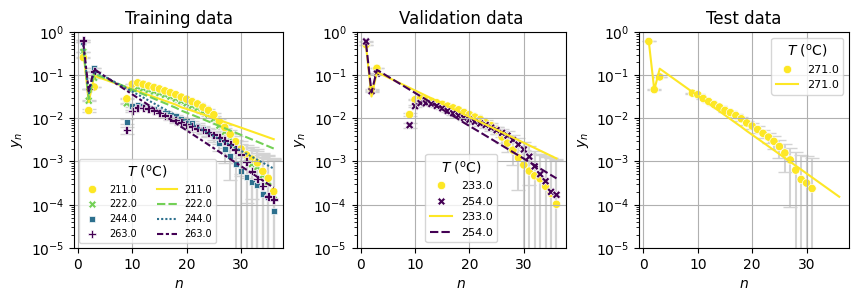

In [49]:
fig, ax = plt.subplots(1,3,figsize=(10, 2.8))
plt.subplots_adjust(wspace=0.35)

scale = 'log'

ax[0].errorbar(
    x=yn_plot_mean.loc[(slice(None), slice(None), 'training')].index.get_level_values("n"), 
    y=yn_plot_mean.loc[(slice(None), slice(None), 'training')]['yn_exp'], 
    yerr=yn_plot_mean.loc[(slice(None), slice(None), 'training')]['sigma_yn_exp'], 
    fmt="none",        # 'none' ensures it doesn't redraw line/markers over scatter
    ecolor="lightgray",     # Error bar line color
    capsize=5,          # Width of the caps at the end of the error bars
    zorder=1,
    # lw = 0.5,
)

sns.scatterplot(x='n', y='yn_exp',
             data=yn_plot_mean.loc[(slice(None), slice(None), 'training')], 
             hue = 'T_R_C', style = 'T_R_C', palette = 'viridis_r', ax = ax[0])

sns.lineplot(x='n', y='yn_C1_C1_mod_model',
             data=yn_plot_mean.loc[(slice(None), slice(None), 'training')], ax = ax[0],
             hue = 'T_R_C', style = 'T_R_C', palette = 'viridis_r')

ax[0].grid('both')
ax[0].legend(title = r'$T~\mathrm{(^oC)}$', fontsize = 7, ncols = 2)
ax[0].set_ylabel(r'$y_n$')
ax[0].set_xlabel(r'$n$')
ax[0].set_yscale(scale)
ax[0].set_title('Training data')
ax[0].set_ylim(1e-5, 1)

ax[1].errorbar(
    x=yn_plot_mean.loc[(slice(None), slice(None), 'validation')].index.get_level_values("n"), 
    y=yn_plot_mean.loc[(slice(None), slice(None), 'validation')]['yn_exp'], 
    yerr=yn_plot_mean.loc[(slice(None), slice(None), 'validation')]['sigma_yn_exp'], 
    fmt="none",        # 'none' ensures it doesn't redraw line/markers over scatter
    ecolor="lightgray",     # Error bar line color
    capsize=5,          # Width of the caps at the end of the error bars
    zorder=1,
    # lw = 0.5,
)

sns.scatterplot(x='n', y='yn_exp',
             data=yn_plot_mean.loc[(slice(None), slice(None), 'validation')], 
             hue = 'T_R_C', style = 'T_R_C', palette = 'viridis_r', ax = ax[1])

sns.lineplot(x='n', y='yn_C1_C1_mod_model',
             data=yn_plot_mean.loc[(slice(None), slice(None), 'validation')], ax = ax[1],
             hue = 'T_R_C', style = 'T_R_C', palette = 'viridis_r')

ax[1].grid('both')
ax[1].legend(title = r'$T~\mathrm{(^oC)}$', fontsize = 8)
ax[1].set_ylabel(r'$y_n$')
ax[1].set_xlabel(r'$n$')
ax[1].set_yscale(scale)
ax[1].set_title('Validation data')
ax[1].set_ylim(1e-5, 1)

ax[2].errorbar(
    x=yn_plot_mean.loc[(slice(None), slice(0, 31), 'test')].index.get_level_values("n"), 
    y=yn_plot_mean.loc[(slice(None), slice(0, 31), 'test')]['yn_exp'], 
    yerr=yn_plot_mean.loc[(slice(None), slice(0, 31), 'test')]['sigma_yn_exp'], 
    fmt="none",        # 'none' ensures it doesn't redraw line/markers over scatter
    ecolor="lightgray",     # Error bar line color
    capsize=5,          # Width of the caps at the end of the error bars
    zorder=1,
    # lw = 1,
)


sns.scatterplot(x='n', y='yn_exp',
             data=yn_plot_mean.loc[(slice(None), slice(None), 'test')], 
             hue = 'T_R_C', style = 'T_R_C', palette = 'viridis_r', ax = ax[2])

sns.lineplot(x='n', y='yn_C1_C1_mod_model',
             data=yn_plot_mean.loc[(slice(None), slice(None), 'test')], ax = ax[2],
             hue = 'T_R_C', style = 'T_R_C', palette = 'viridis_r')

ax[2].grid('both')
ax[2].legend(title = r'$T~\mathrm{(^oC)}$', fontsize = 8)
ax[2].set_ylabel(r'$y_n$')
ax[2].set_xlabel(r'$n$')
ax[2].set_yscale(scale)
ax[2].set_title('Test data')
ax[2].set_ylim(1e-5, 1)

fig_name = 'figure-y_n_distribution.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
            bbox_inches = 'tight')

plt.show()

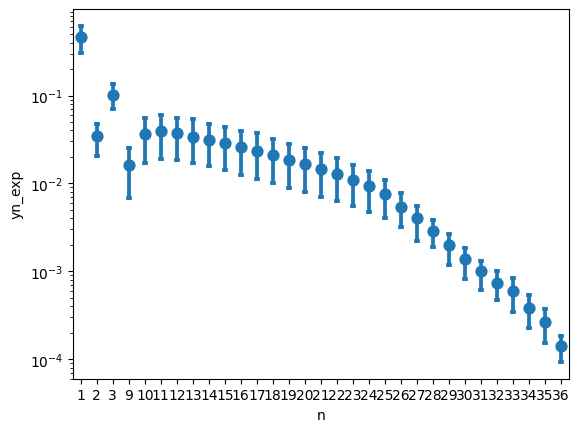

In [39]:
sns.pointplot(
    data=yn_plot_mean.loc[(slice(None), slice(None), 'training')], 
    x="n", 
    y="yn_exp", 
    linestyle="none",     # Removes the connecting line
    marker="o",           # Keeps the dots looking like a scatter plot
    errorbar="ci",        # Shows 95% Confidence Interval (use "sd" for Std Dev)
    capsize=0.1           # Adds horizontal caps to the error bars
)

plt.yscale('log')

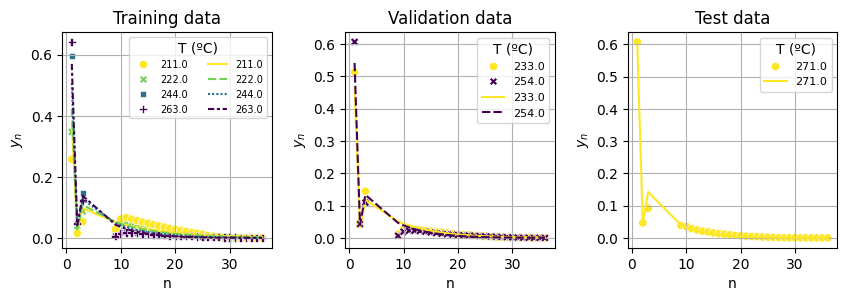

In [40]:
fig, ax = plt.subplots(1,3,figsize=(10, 2.8))
plt.subplots_adjust(wspace=0.35)

scale = 'linear'

sns.scatterplot(x='n', y='yn_exp',
             data=yn_plot_mean.loc[(slice(None), slice(None), 'training')], 
             hue = 'T_R_C', style = 'T_R_C', palette = 'viridis_r', ax = ax[0])

sns.lineplot(x='n', y='yn_C1_C1_mod_model',
             data=yn_plot_mean.loc[(slice(None), slice(None), 'training')], ax = ax[0],
             hue = 'T_R_C', style = 'T_R_C', palette = 'viridis_r')

ax[0].grid('both')
ax[0].legend(title = 'T (ºC)', fontsize = 7, ncols = 2)
ax[0].set_ylabel(r'$y_n$')
ax[0].set_yscale(scale)
ax[0].set_title('Training data')

sns.scatterplot(x='n', y='yn_exp',
             data=yn_plot_mean.loc[(slice(None), slice(None), 'validation')], 
             hue = 'T_R_C', style = 'T_R_C', palette = 'viridis_r', ax = ax[1])

sns.lineplot(x='n', y='yn_C1_C1_mod_model',
             data=yn_plot_mean.loc[(slice(None), slice(None), 'validation')], ax = ax[1],
             hue = 'T_R_C', style = 'T_R_C', palette = 'viridis_r')

ax[1].grid('both')
ax[1].legend(title = 'T (ºC)', fontsize = 8)
ax[1].set_ylabel(r'$y_n$')
ax[1].set_yscale(scale)
ax[1].set_title('Validation data')

sns.scatterplot(x='n', y='yn_exp',
             data=yn_plot_mean.loc[(slice(None), slice(None), 'test')], 
             hue = 'T_R_C', style = 'T_R_C', palette = 'viridis_r', ax = ax[2])

sns.lineplot(x='n', y='yn_C1_C1_mod_model',
             data=yn_plot_mean.loc[(slice(None), slice(None), 'test')], ax = ax[2],
             hue = 'T_R_C', style = 'T_R_C', palette = 'viridis_r')

ax[2].grid('both')
ax[2].legend(title = 'T (ºC)', fontsize = 8)
ax[2].set_ylabel(r'$y_n$')
ax[2].set_yscale(scale)
ax[2].set_title('Test data')

# fig_name = 'y_n_distribution.pdf'
# plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
#             bbox_inches = 'tight')

plt.show()